# Pandas Fundamentals - Complete Guide
## Data Manipulation and Analysis with Python

## 1. Introduction to Pandas

**What is Pandas?**
- Pandas is the most popular Python library for data manipulation and analysis
- It provides high-performance, easy-to-use data structures
- Built on top of NumPy (which we learned earlier)
- It's the foundation for data science and machine learning workflows

**Key Benefits:**
- **Data Structures**: Powerful DataFrame and Series objects
- **Data Cleaning**: Handle missing data, duplicates, and outliers
- **Data Manipulation**: Filter, sort, group, merge, and reshape data
- **Data Analysis**: Statistical summaries, aggregations, and transformations
- **I/O Capabilities**: Read/write from CSV, Excel, SQL, JSON, and more
- **Time Series**: Excellent support for date/time data

**Pandas vs NumPy:**
- NumPy: Low-level numerical operations on homogeneous arrays
- Pandas: High-level data manipulation on labeled, heterogeneous data

In [5]:
import pandas as pd
import numpy as np
print(f"Pandas version: {pd.__version__}")

# IMPORTANT: By convention, we import pandas as 'pd'

Pandas version: 2.2.3


## 2. Pandas Data Structures

### 2.1 Series (1-Dimensional)

**What is a Series?**
- A Series is a one-dimensional labeled array
- Like a column in a spreadsheet or a dictionary with ordered keys
- Each element has an index label (can be custom or default integer)
- Can hold any data type (integers, strings, floats, Python objects)

**Key Properties:**
- **index**: Labels for each element
- **values**: The actual data (as a NumPy array)
- **dtype**: Data type of the elements
- **size**: Number of elements
- **name**: Optional name for the Series


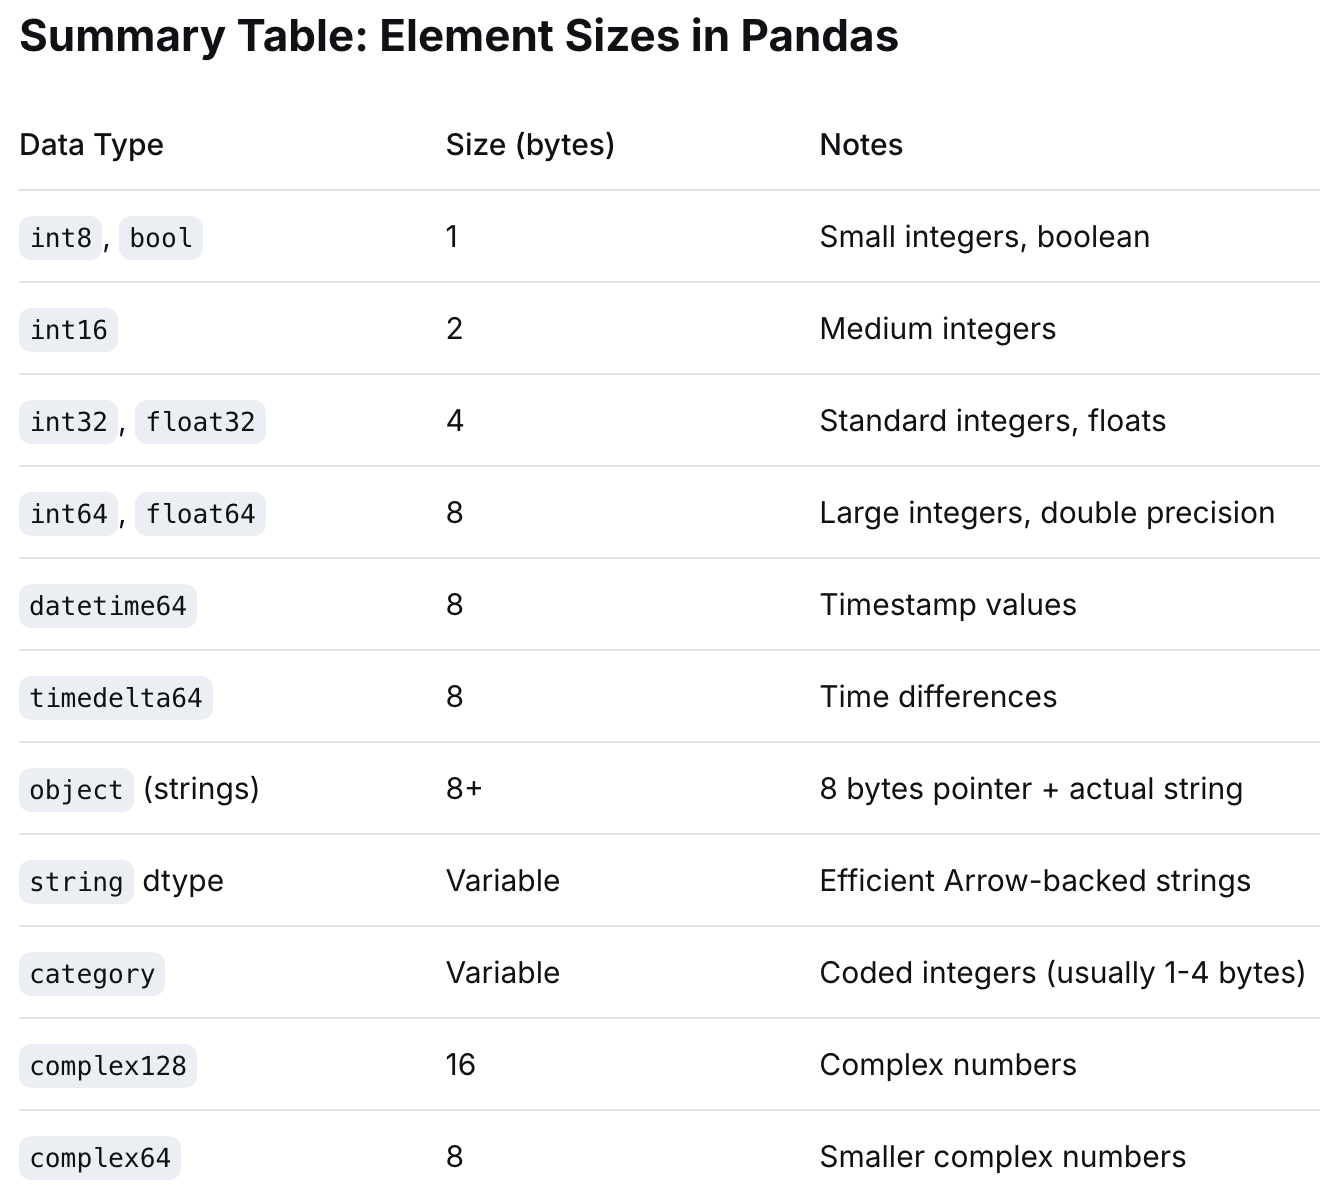

In [6]:
print("--- Creating Series ---")

# 1. From a list (default integer index)
s1 = pd.Series([10, 20, 30, 40, 50])
print("Series from list:\n", s1)

# 2. From a list with custom index labels
s2 = pd.Series([10, 20, 30, 40, 50], index=['a', 'b', 'c', 'd', 'e'])
print("\nSeries with custom index:\n", s2)

# 3. From a dictionary (keys become index, values become data)
data = {'Name': 'Alice', 'Age': 30, 'City': 'New York'}
s3 = pd.Series(data)
print("\nSeries from dictionary:\n", s3)

# 4. From a scalar (repeated value)
s4 = pd.Series(5, index=['x', 'y', 'z'])
print("\nSeries from scalar:\n", s4)

print("\n--- Series Properties ---")
print(f"Index: {s2.index}")
print(f"Values: {s2.values}")
print(f"Data type: {s2.dtype}")
print(f"Size: {s2.size}")
print(f"Shape: {s2.shape}")
print(f"Name: {s2.name}")  # None by default

--- Creating Series ---
Series from list:
 0    10
1    20
2    30
3    40
4    50
dtype: int64

Series with custom index:
 a    10
b    20
c    30
d    40
e    50
dtype: int64

Series from dictionary:
 Name       Alice
Age           30
City    New York
dtype: object

Series from scalar:
 x    5
y    5
z    5
dtype: int64

--- Series Properties ---
Index: Index(['a', 'b', 'c', 'd', 'e'], dtype='object')
Values: [10 20 30 40 50]
Data type: int64
Size: 5
Shape: (5,)
Name: None


### 2.2 DataFrame (2-Dimensional)

**What is a DataFrame?**
- A DataFrame is a two-dimensional labeled data structure
- Like a spreadsheet, Excel table, or SQL table
- Has both row index and column labels
- Each column can have different data types
- The most commonly used Pandas object

**Key Components:**
- **Columns**: Labels for each column (like field names)
- **Index**: Labels for each row (like record IDs)
- **Values**: The actual data (as a 2D NumPy array)
- **dtypes**: Data type of each column
- **shape**: (rows, columns)

In [17]:
print("--- Creating DataFrames ---")

# 1. From a dictionary of lists (most common)
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'Age': [25, 30, 35, 28, 32],
    'Salary': [50000, 60000, 75000, 58000, 68000],
    'City': ['NYC', 'LA', 'Chicago', 'NYC', 'LA']
}
df = pd.DataFrame(data)
print("DataFrame from dictionary:\n", df)

# 2. From a list of dictionaries
data_list = [
    {'Name': 'Alice', 'Age': 25, 'City': 'NYC'},
    {'Name': 'Bob', 'Age': 30, 'City': 'LA'},
    {'Name': 'Charlie', 'Age': 35, 'City': 'Chicago'}
]
df2 = pd.DataFrame(data_list)
print("\nDataFrame from list of dicts:\n", df2)

# 3. From a NumPy array
arr = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
df3 = pd.DataFrame(arr, columns=['A', 'B', 'C'], index=['r1', 'r2', 'r3'])
print("\nDataFrame from NumPy array:\n", df3)

print("\n--- DataFrame Properties ---")
print(f"Shape: {df.shape}")  # (rows, columns)
print(f"Columns: {df.columns.tolist()}")
print(f"Index: {df.index.tolist()}")
print(f"Data types:\n{df.dtypes}")
print(f"Total elements: {df.size}")

--- Creating DataFrames ---
DataFrame from dictionary:
       Name  Age  Salary     City
0    Alice   25   50000      NYC
1      Bob   30   60000       LA
2  Charlie   35   75000  Chicago
3    Diana   28   58000      NYC
4      Eve   32   68000       LA

DataFrame from list of dicts:
       Name  Age     City
0    Alice   25      NYC
1      Bob   30       LA
2  Charlie   35  Chicago

DataFrame from NumPy array:
     A  B  C
r1  1  2  3
r2  4  5  6
r3  7  8  9

--- DataFrame Properties ---
Shape: (5, 4)
Columns: ['Name', 'Age', 'Salary', 'City']
Index: [0, 1, 2, 3, 4]
Data types:
Name      object
Age        int64
Salary     int64
City      object
dtype: object
Total elements: 20


## 3. Loading Datasets

**Reading Data from Different Sources:**
1. **CSV**: `pd.read_csv()` - Most common
2. **Excel**: `pd.read_excel()` - Spreadsheet files
3. **JSON**: `pd.read_json()` - Web APIs, JSON files
4. **SQL**: `pd.read_sql()` - Databases
5. **HTML**: `pd.read_html()` - Web tables
6. **Clipboard**: `pd.read_clipboard()` - Copy from Excel/Google Sheets

**Key Parameters for read_csv():**
- `filepath`: Path to file or URL
- `sep`: Delimiter (default is ',')
- `header`: Row to use as column names
- `index_col`: Column to use as row index
- `usecols`: Columns to read
- `nrows`: Number of rows to read
- `skiprows`: Rows to skip
- `na_values`: Values to treat as NaN

In [21]:
print("--- Creating Sample Data for Demonstration ---")

# Create a sample CSV data as string (instead of a file)
import io
csv_data = """Name,Age,Salary,Department,Join_Date
John Doe,28,55000,Engineering,2020-01-15
Jane Smith,34,72000,Sales,2019-05-20
Bob Johnson,45,85000,Engineering,2018-03-10
Alice Brown,29,61000,Marketing,2021-02-01
Charlie Wilson,38,78000,Sales,2017-11-30
Diana Lee,26,52000,Engineering,2022-06-15
Eve Adams,32,68000,Marketing,2020-08-20
Frank Chen,41,92000,Engineering,2016-04-12
Grace Kim,35,74000,Sales,2019-09-05
Henry Park,29,59000,Marketing,2021-07-18"""

# Read CSV from string (normally you'd use pd.read_csv('filename.csv'))
df = pd.read_csv(io.StringIO(csv_data))
print("Loaded DataFrame:\n", df)

print("\n--- Quick Overview of Data ---")
print("First 5 rows:\n", df.head())  # First 5 rows
print("\nLast 3 rows:\n", df.tail(3))  # Last 3 rows
print("\nShape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nBasic info:")
df.info()

# print("=*8")
# df.describe()
print("\n--- Loading Other Formats (Examples) ---")
# These are commented out as they require actual files
# df_excel = pd.read_excel('data.xlsx')
# df_json = pd.read_json('data.json')
# df_csv = pd.read_csv('data.csv', sep=';', encoding='utf-8')

--- Creating Sample Data for Demonstration ---
Loaded DataFrame:
              Name  Age  Salary   Department   Join_Date
0        John Doe   28   55000  Engineering  2020-01-15
1      Jane Smith   34   72000        Sales  2019-05-20
2     Bob Johnson   45   85000  Engineering  2018-03-10
3     Alice Brown   29   61000    Marketing  2021-02-01
4  Charlie Wilson   38   78000        Sales  2017-11-30
5       Diana Lee   26   52000  Engineering  2022-06-15
6       Eve Adams   32   68000    Marketing  2020-08-20
7      Frank Chen   41   92000  Engineering  2016-04-12
8       Grace Kim   35   74000        Sales  2019-09-05
9      Henry Park   29   59000    Marketing  2021-07-18

--- Quick Overview of Data ---
First 5 rows:
              Name  Age  Salary   Department   Join_Date
0        John Doe   28   55000  Engineering  2020-01-15
1      Jane Smith   34   72000        Sales  2019-05-20
2     Bob Johnson   45   85000  Engineering  2018-03-10
3     Alice Brown   29   61000    Marketing  20

## 4. Viewing and Inspecting Data

**Common Methods for Data Exploration:**
- **head()**: First n rows (default 5)
- **tail()**: Last n rows (default 5)
- **info()**: Summary of DataFrame (columns, non-null counts, dtypes)
- **describe()**: Statistical summary of numerical columns
- **shape**: Tuple of (rows, columns)
- **columns**: List of column names
- **index**: Row index labels
- **dtypes**: Data types of each column
- **value_counts()**: Count of unique values in a column
- **unique()**: Unique values in a column
- **sample()**: Random sample of rows
- **memory_usage()**: Memory usage of DataFrame

In [22]:
print("--- Data Inspection Methods ---")

# Create a larger dataset
np.random.seed(42)
n = 100
large_data = {
    'ID': np.arange(1, n+1),
    'Age': np.random.randint(18, 65, n),
    'Salary': np.random.randint(30000, 100000, n),
    'Score': np.random.uniform(0, 100, n).round(2),
    'Department': np.random.choice(['Engineering', 'Sales', 'Marketing', 'HR'], n),
    'Active': np.random.choice([True, False], n, p=[0.8, 0.2])
}
df_large = pd.DataFrame(large_data)

print("DataFrame Shape:", df_large.shape)
print("\nFirst 5 rows:\n", df_large.head())
print("\nLast 2 rows:\n", df_large.tail(2))
print("\nRandom sample (3 rows):\n", df_large.sample(3))

print("\n--- DataFrame Info ---")
df_large.info()

print("\n--- Statistical Summary ---")
print(df_large.describe())

print("\n--- Column Summary ---")
print("Columns:", df_large.columns.tolist())
print("\nData types:\n", df_large.dtypes)
print("\nValue counts of Department:")
print(df_large['Department'].value_counts())

print("\nUnique (Distinct) values in Department:", df_large['Department'].unique())
print("\nMemory usage:", df_large.memory_usage(deep=True))

--- Data Inspection Methods ---
DataFrame Shape: (100, 6)

First 5 rows:
    ID  Age  Salary  Score Department  Active
0   1   56   32695  32.60      Sales    True
1   2   46   78190  22.02  Marketing    True
2   3   32   35258  71.11      Sales    True
3   4   60   69504  80.95  Marketing   False
4   5   25   63159  34.87      Sales    True

Last 2 rows:
      ID  Age  Salary  Score Department  Active
98   99   18   45708  70.89  Marketing    True
99  100   61   79811  55.28      Sales    True

Random sample (3 rows):
     ID  Age  Salary  Score   Department  Active
50  51   45   51976  72.09  Engineering    True
96  97   26   72107  84.87        Sales    True
1    2   46   78190  22.02    Marketing    True

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          100 non-null    int64  
 1   Age         100 non-null   

## 5. Filtering and Selecting Data

**Ways to Select Data:**

1. **Selecting Columns:**
   - `df['column']` - Single column (returns Series)
   - `df[['col1', 'col2']]` - Multiple columns (returns DataFrame)
   - `df.column` - Access column as attribute (if name is valid)

2. **Selecting Rows:**
   - `df.loc[index_label]` - Select by index label
   - `df.iloc[position]` - Select by integer position
   - `df.head()`, `df.tail()` - First/last rows

3. **Filtering with Conditions:**
   - `df[df['column'] > value]` - Boolean indexing
   - Multiple conditions: `&` (and), `|` (or), `~` (not)
   - `df.query('column > value')` - Query string syntax
   - `df.isin([values])` - Check if value is in list

4. **Selection with loc/iloc:**
   - `df.loc[rows, columns]` - Select by label
   - `df.iloc[row_positions, col_positions]` - Select by position

**Important:**
- `loc` uses labels (index/column names)
- `iloc` uses integer positions (like NumPy indexing)
- `df[condition]` returns rows where condition is True

In [24]:
print("--- Selecting Columns ---")

# Use the employee DataFrame
df = pd.read_csv(io.StringIO(csv_data))
print("Original DataFrame:\n", df)

# Single column (returns Series)
print("\nSingle column (Name):\n", df['Name'])

# Multiple columns (returns DataFrame)
print("\nMultiple columns (Name, Salary):\n", df[['Name', 'Salary']])

# Access as attribute (if column name has no spaces)
print("\nAccess as attribute (Name):\n", df.Name)

print("\n--- Selecting Rows ---")
# By index label (loc)
print("Row at index 2:\n", df.loc[2])

# By position (iloc)
print("\nRow at position 2:\n", df.iloc[2])

# Slicing rows
print("\nRows 2 to 5:\n", df[2:6])

print("\n--- Filtering with Conditions ---")
# Single condition
print("Employees with salary > 70000:\n", df[df['Salary'] > 70000])

# Multiple conditions (AND)
filtered = df[(df['Salary'] > 60000) & (df['Department'] == 'Engineering')]
print("\nEngineering employees with salary > 60000:\n", filtered)

# Multiple conditions (OR)
filtered = df[(df['Department'] == 'Sales') | (df['Department'] == 'Marketing')]
print("\nSales or Marketing employees:\n", filtered)

# NOT condition
print("\nNot Engineering employees:\n", df[~(df['Department'] == 'Engineering')])

# Using isin()
depts = ['Engineering', 'Sales']
print("\nEngineering or Sales departments:\n", df[df['Department'].isin(depts)])

print("\n--- Using loc for Combined Selection ---")
# Select specific rows and columns
print("Name and Salary of rows 2-4:\n", df.loc[2:4, ['Name', 'Salary']])

# With conditions using loc
print("\nName and Age of employees > 35:\n", df.loc[df['Age'] > 35, ['Name', 'Age']])

--- Selecting Columns ---
Original DataFrame:
              Name  Age  Salary   Department   Join_Date
0        John Doe   28   55000  Engineering  2020-01-15
1      Jane Smith   34   72000        Sales  2019-05-20
2     Bob Johnson   45   85000  Engineering  2018-03-10
3     Alice Brown   29   61000    Marketing  2021-02-01
4  Charlie Wilson   38   78000        Sales  2017-11-30
5       Diana Lee   26   52000  Engineering  2022-06-15
6       Eve Adams   32   68000    Marketing  2020-08-20
7      Frank Chen   41   92000  Engineering  2016-04-12
8       Grace Kim   35   74000        Sales  2019-09-05
9      Henry Park   29   59000    Marketing  2021-07-18

Single column (Name):
 0          John Doe
1        Jane Smith
2       Bob Johnson
3       Alice Brown
4    Charlie Wilson
5         Diana Lee
6         Eve Adams
7        Frank Chen
8         Grace Kim
9        Henry Park
Name: Name, dtype: object

Multiple columns (Name, Salary):
              Name  Salary
0        John Doe   55000


## 6. Sorting Data

**Sorting Methods:**

1. **sort_values()**: Sort by column values
   - `by`: Column(s) to sort by
   - `ascending`: True for ascending, False for descending
   - `inplace`: Modify DataFrame in place
   - `na_position`: Where to place NaN values ('first' or 'last')

2. **sort_index()**: Sort by index labels
   - `ascending`: True for ascending
   - `inplace`: Modify in place

**Important:**
- Sorting doesn't modify the index by default
- Use `reset_index(drop=True)` if you want to reset index after sorting

In [11]:
print("--- Sorting Data ---")

df = pd.read_csv(io.StringIO(csv_data))
print("Original DataFrame:\n", df)

print("\n--- Sort by Single Column ---")
# Sort by Age (ascending)
sorted_by_age = df.sort_values('Age')
print("Sorted by Age (ascending):\n", sorted_by_age)

# Sort by Salary (descending)
sorted_by_salary = df.sort_values('Salary', ascending=False)
print("\nSorted by Salary (descending):\n", sorted_by_salary)

print("\n--- Sort by Multiple Columns ---")
# Sort by Department first, then by Salary
sorted_multi = df.sort_values(['Department', 'Salary'], ascending=[True, False])
print("Sorted by Department (ascending) then Salary (descending):\n", sorted_multi)

print("\n--- Sort by Index ---")
# Create a shuffled DataFrame
df_shuffled = df.sample(frac=1).reset_index(drop=True)
print("Shuffled DataFrame:\n", df_shuffled)

# Sort by index
sorted_index = df_shuffled.sort_index()
print("\nSorted by index:\n", sorted_index)

print("\n--- In-place Sorting ---")
df_copy = df.copy()
df_copy.sort_values('Age', inplace=True)
print("Modified in-place:\n", df_copy)

--- Sorting Data ---
Original DataFrame:
              Name  Age  Salary   Department   Join_Date
0        John Doe   28   55000  Engineering  2020-01-15
1      Jane Smith   34   72000        Sales  2019-05-20
2     Bob Johnson   45   85000  Engineering  2018-03-10
3     Alice Brown   29   61000    Marketing  2021-02-01
4  Charlie Wilson   38   78000        Sales  2017-11-30
5       Diana Lee   26   52000  Engineering  2022-06-15
6       Eve Adams   32   68000    Marketing  2020-08-20
7      Frank Chen   41   92000  Engineering  2016-04-12
8       Grace Kim   35   74000        Sales  2019-09-05
9      Henry Park   29   59000    Marketing  2021-07-18

--- Sort by Single Column ---
Sorted by Age (ascending):
              Name  Age  Salary   Department   Join_Date
5       Diana Lee   26   52000  Engineering  2022-06-15
0        John Doe   28   55000  Engineering  2020-01-15
3     Alice Brown   29   61000    Marketing  2021-02-01
9      Henry Park   29   59000    Marketing  2021-07-18
6  

## 7. Handling Missing Values

**Understanding Missing Values:**
- In Pandas, missing values are represented as `NaN` (Not a Number)
- Missing values can come from various sources:
  - Data entry errors
  - Incomplete records
  - Merging datasets
  - Survey non-response

**Detecting Missing Values:**
- `isna()` / `isnull()`: Detect missing values
- `notna()` / `notnull()`: Detect non-missing values
- `info()`: Shows non-null counts
- `value_counts(dropna=False)`: Counts including NaNs

**Handling Missing Values:**
1. **Drop**: Remove rows/columns with missing values
   - `dropna()`: Remove rows with any missing values
   - `dropna(how='all')`: Remove rows where all values are missing
   - `dropna(thresh=n)`: Remove rows with less than n non-null values
   - `dropna(axis=1)`: Drop columns with missing values

2. **Fill**: Replace missing values with a value
   - `fillna(value)`: Fill with a specific value
   - `fillna(method='ffill')`: Forward fill (use previous value)
   - `fillna(method='bfill')`: Backward fill (use next value)
   - `fillna(df.mean())`: Fill with mean of column
   - `fillna(df.median())`: Fill with median
   - `fillna(df.mode())`: Fill with mode

3. **Interpolate**: Use interpolation to estimate missing values
   - `interpolate()`: Linear interpolation

In [12]:
print("--- Creating DataFrame with Missing Values ---")

# Create data with missing values
data_with_nan = {
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'Age': [25, np.nan, 35, 28, 32],
    'Salary': [50000, 60000, np.nan, 58000, np.nan],
    'Department': ['Engineering', 'Sales', np.nan, 'Marketing', 'Sales'],
    'Score': [85, 90, 78, np.nan, 92]
}
df_missing = pd.DataFrame(data_with_nan)
print("DataFrame with missing values:\n", df_missing)

print("\n--- Detecting Missing Values ---")
print("isnull() (True where missing):\n", df_missing.isnull())
print("\nSum of missing values per column:\n", df_missing.isnull().sum())
print("\nTotal missing values:", df_missing.isnull().sum().sum())
print("\nNon-null counts:\n", df_missing.info())

print("\n--- Dropping Missing Values ---")
# Drop rows with any missing value
df_dropped = df_missing.dropna()
print("After dropping rows with any missing value:\n", df_dropped)

# Drop rows where ALL values are missing
df_missing_all = df_missing.copy()
# Add a new row
df_missing_all.loc[5] = [np.nan, np.nan, np.nan, np.nan, np.nan]
print("\nDataFrame with new row:\n", df_missing_all)
print("\nDrop rows where all values are missing:\n", df_missing_all.dropna(how='all'))

print("\n--- Filling Missing Values ---")
# Fill with a specific value
df_filled = df_missing.fillna(0)
print("Fill all NaN with 0:\n", df_filled)

# Fill different columns with different values
df_filled_specific = df_missing.fillna({'Age': 30, 'Salary': 60000, 'Score': 85})
print("\nFill specific columns with specific values:\n", df_filled_specific)

# Forward fill (use previous value)
df_ffill = df_missing.ffill()
print("\nForward fill (using previous value):\n", df_ffill)

# Fill with column statistics
print("\nFill with mean values:")
df_mean_fill = df_missing.copy()
df_mean_fill['Age'] = df_mean_fill['Age'].fillna(df_mean_fill['Age'].mean())
df_mean_fill['Salary'] = df_mean_fill['Salary'].fillna(df_mean_fill['Salary'].mean())
df_mean_fill['Score'] = df_mean_fill['Score'].fillna(df_mean_fill['Score'].mean())
print(df_mean_fill)

print("\n--- Advanced: Interpolation ---")
# Create sequence with missing values
df_interp = pd.DataFrame({'Values': [1, 2, np.nan, 4, 5, np.nan, 7, 8, 9, 10]})
print("Original with missing:\n", df_interp)
print("\nLinear interpolation:\n", df_interp.interpolate())

--- Creating DataFrame with Missing Values ---
DataFrame with missing values:
       Name   Age   Salary   Department  Score
0    Alice  25.0  50000.0  Engineering   85.0
1      Bob   NaN  60000.0        Sales   90.0
2  Charlie  35.0      NaN          NaN   78.0
3    Diana  28.0  58000.0    Marketing    NaN
4      Eve  32.0      NaN        Sales   92.0

--- Detecting Missing Values ---
isnull() (True where missing):
     Name    Age  Salary  Department  Score
0  False  False   False       False  False
1  False   True   False       False  False
2  False  False    True        True  False
3  False  False   False       False   True
4  False  False    True       False  False

Sum of missing values per column:
 Name          0
Age           1
Salary        2
Department    1
Score         1
dtype: int64

Total missing values: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      ---------

## 8. Grouping and Aggregation

**The Split-Apply-Combine Pattern:**
1. **Split**: Group data by some criteria
2. **Apply**: Apply a function to each group independently
3. **Combine**: Combine the results into a new data structure

**Key Methods:**

1. **groupby()**: Group data by columns
   - `df.groupby('column')`: Group by one column
   - `df.groupby(['col1', 'col2'])`: Group by multiple columns

2. **Aggregation Functions**:
   - `mean()`, `sum()`, `count()`, `min()`, `max()`, `std()`, `var()`
   - `agg()`: Custom aggregations (list of functions)
   - `agg({'col1': 'mean', 'col2': 'sum'})`: Different functions per column

3. **Transform**: Apply function that returns same shape
   - `transform()`: Apply function to each group

4. **Filter**: Filter groups
   - `filter()`: Filter groups based on condition

5. **Pivot Tables**:
   - `pivot_table()`: Create pivot table (like Excel)
   - `crosstab()`: Cross-tabulation

In [13]:
print("--- Creating Data for Grouping Examples ---")

np.random.seed(42)
n = 100
sales_data = {
    'Region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'Product': np.random.choice(['A', 'B', 'C', 'D'], n),
    'Sales': np.random.randint(100, 1000, n),
    'Quantity': np.random.randint(1, 50, n),
    'Month': np.random.choice(['Jan', 'Feb', 'Mar', 'Apr', 'May'], n)
}
df_sales = pd.DataFrame(sales_data)
print("Sales Data (first 10 rows):\n", df_sales.head(10))

print("\n--- Group by Single Column ---")
# Group by Region and calculate mean Sales
region_sales = df_sales.groupby('Region')['Sales'].mean()
print("Average Sales by Region:\n", region_sales)

# Group by Region with multiple aggregations
region_stats = df_sales.groupby('Region')['Sales'].agg(['mean', 'sum', 'count', 'std'])
print("\nSales Statistics by Region:\n", region_stats)

print("\n--- Group by Multiple Columns ---")
# Group by Region and Product
region_product_sales = df_sales.groupby(['Region', 'Product'])['Sales'].sum()
print("Total Sales by Region and Product:\n", region_product_sales)

print("\n--- Aggregating Multiple Columns ---")
# Different aggregations for different columns
agg_dict = {
    'Sales': ['mean', 'sum', 'max'],
    'Quantity': ['mean', 'sum', 'min']
}
multi_agg = df_sales.groupby('Region').agg(agg_dict)
print("Multiple aggregations:\n", multi_agg)

# print("\n--- Custom Aggregation Functions ---")
# # Define custom functions
# def range_calc(x):
#     return x.max() - x.min()

# custom_agg = df_sales.groupby('Product')['Sales'].agg(['mean', 'sum', range_calc])
# print("Custom aggregation (range):\n", custom_agg)

print("\n--- Using transform() ---")
# Add group means as a new column
df_sales['Region_Avg_Sales'] = df_sales.groupby('Region')['Sales'].transform('mean')
print("Original with group averages:\n", df_sales[['Region', 'Sales', 'Region_Avg_Sales']].head(10))

print("\n--- Pivot Tables (Excel-like) ---")
# Create a pivot table
pivot = pd.pivot_table(
    df_sales,
    values='Sales',
    index='Region',
    columns='Product',
    aggfunc='mean'
)
print("Pivot Table: Average Sales by Region and Product\n", pivot)

print("\n--- Cross Tabulation ---")
crosstab = pd.crosstab(df_sales['Region'], df_sales['Product'])
print("Cross-tabulation (counts):\n", crosstab)

--- Creating Data for Grouping Examples ---
Sales Data (first 10 rows):
   Region Product  Sales  Quantity Month
0   East       C    674        32   Apr
1   West       B    963         4   Mar
2  North       B    842        11   Mar
3   East       D    340        17   May
4   East       B    663        38   Mar
5   West       B    195        24   Mar
6  North       B    999         5   Mar
7  North       D    833        34   Feb
8   East       B    584         6   May
9  South       C    506        22   Jan

--- Group by Single Column ---
Average Sales by Region:
 Region
East     553.791667
North    670.300000
South    586.038462
West     550.600000
Name: Sales, dtype: float64

Sales Statistics by Region:
               mean    sum  count         std
Region                                      
East    553.791667  13291     24  244.350778
North   670.300000  13406     20  221.238880
South   586.038462  15237     26  221.115622
West    550.600000  16518     30  256.746836

--- Group by 

## 9. Exploratory Data Analysis (EDA)

**What is EDA?**
- Exploratory Data Analysis is the process of analyzing data to understand its main characteristics
- It's the first step in any data science project
- Helps identify patterns, outliers, and relationships

**Key EDA Tasks:**
1. **Data Overview**: Shape, columns, data types, first/last rows
2. **Summary Statistics**: Descriptive statistics for numerical columns
3. **Distribution Analysis**: Histograms, box plots, value counts
4. **Missing Values**: Identify and handle missing data
5. **Correlation Analysis**: Relationship between variables
6. **Outlier Detection**: Identify unusual values
7. **Visualization**: Create plots to understand data
8. **Data Quality**: Check for duplicates, inconsistencies

In [14]:
print("--- 1. Data Overview ---")

# Load the employee dataset (already have)
df = pd.read_csv(io.StringIO(csv_data))
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nFirst 3 rows:\n", df.head(3))
print("\nLast 3 rows:\n", df.tail(3))

print("\n--- 2. Summary Statistics ---")
# Summary for numerical columns
print("Numerical Columns Summary:\n", df.describe())

# Summary for categorical columns
print("\nCategorical Columns Summary:\n", df.describe(include=['object']))

print("\n--- 3. Distribution Analysis ---")
print("Department Distribution:")
print(df['Department'].value_counts())
print("\nDepartment Distribution (%):")
print(df['Department'].value_counts(normalize=True) * 100)

print("\n--- 4. Missing Value Analysis ---")
print("Missing values per column:\n", df.isnull().sum())
print("\nPercentage of missing values:\n", (df.isnull().sum() / len(df)) * 100)

print("\n--- 5. Correlation Analysis ---")
# Select only numerical columns
numeric_df = df.select_dtypes(include=[np.number])
print("Correlation Matrix:\n", numeric_df.corr())

# Strong correlations
corr_matrix = numeric_df.corr()
print("\nStrong correlations (> 0.5 or < -0.5):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            print(f"{corr_matrix.columns[i]} and {corr_matrix.columns[j]}: {corr_val:.3f}")

print("\n--- 6. Outlier Detection (using IQR method) ---")
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

print("Outliers in Salary:")
outliers, lower, upper = detect_outliers(df, 'Salary')
print(f"Lower bound: {lower:.2f}, Upper bound: {upper:.2f}")
print(f"Number of outliers: {len(outliers)}")
print("Outlier rows:\n", outliers)

print("\n--- 7. Data Quality Checks ---")
print(f"Number of duplicates: {df.duplicated().sum()}")
print("\nUnique values in each column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

--- 1. Data Overview ---
Dataset Shape: (10, 5)

Column Names: ['Name', 'Age', 'Salary', 'Department', 'Join_Date']

Data Types:
 Name          object
Age            int64
Salary         int64
Department    object
Join_Date     object
dtype: object

First 3 rows:
           Name  Age  Salary   Department   Join_Date
0     John Doe   28   55000  Engineering  2020-01-15
1   Jane Smith   34   72000        Sales  2019-05-20
2  Bob Johnson   45   85000  Engineering  2018-03-10

Last 3 rows:
          Name  Age  Salary   Department   Join_Date
7  Frank Chen   41   92000  Engineering  2016-04-12
8   Grace Kim   35   74000        Sales  2019-09-05
9  Henry Park   29   59000    Marketing  2021-07-18

--- 2. Summary Statistics ---
Numerical Columns Summary:
              Age        Salary
count  10.000000     10.000000
mean   33.700000  69600.000000
std     6.147267  13108.097582
min    26.000000  52000.000000
25%    29.000000  59500.000000
50%    33.000000  70000.000000
75%    37.250000  77000.

## 10. Advanced: Data Manipulation Operations

**Common Data Manipulation Tasks:**

1. **Adding/Modifying Columns:**
   - `df['new_col'] = values` - Add new column
   - `df['col'] = df['col'].apply(function)` - Apply function to column
   - `df['new'] = df['col1'] + df['col2']` - Create from calculations

2. **Renaming Columns:**
   - `df.rename(columns={'old': 'new'})` - Rename columns
   - `df.columns = ['col1', 'col2']` - Rename all columns

3. **Dropping Data:**
   - `df.drop('column', axis=1)` - Drop column
   - `df.drop(rows, axis=0)` - Drop rows

4. **Applying Functions:**
   - `apply()` - Apply function to rows/columns
   - `applymap()` - Apply function element-wise
   - `map()` - Map values using dictionary

5. **Merging/Joining:**
   - `pd.merge(df1, df2, on='key')` - Merge two DataFrames
   - `df1.join(df2)` - Join DataFrames
   - `pd.concat([df1, df2])` - Concatenate DataFrames

In [15]:
print("--- 1. Adding and Modifying Columns ---")

df = pd.read_csv(io.StringIO(csv_data))
print("Original DataFrame:\n", df)

# Add new column (bonus = 10% of salary)
df['Bonus'] = df['Salary'] * 0.10
print("\nAfter adding Bonus column:\n", df)

# Add new column based on condition
df['Salary_Level'] = np.where(df['Salary'] > 70000, 'High', 'Low')
print("\nAfter adding Salary_Level:\n", df)

# Apply function to column
df['Name_Length'] = df['Name'].apply(lambda x: len(x))
print("\nAfter adding Name_Length:\n", df)

print("\n--- 2. Renaming Columns ---")
# Rename specific columns
df_renamed = df.rename(columns={'Name': 'Full_Name', 'Salary': 'Annual_Salary'})
print("Renamed columns:\n", df_renamed.columns.tolist())

# Rename all columns (using a list)
df_renamed2 = df.copy()
df_renamed2.columns = ['Emp_Name', 'Emp_Age', 'Emp_Salary', 'Dept', 'Join_Date', 'Bonus', 'Level', 'Name_Len']
print("Renamed all columns:\n", df_renamed2.columns.tolist())

print("\n--- 3. Dropping Data ---")
# Drop column
df_dropped = df.drop('Bonus', axis=1)
print("After dropping 'Bonus' column:\n", df_dropped.columns.tolist())

# Drop rows (by index)
df_dropped_rows = df.drop([0, 2, 4])  # Drop rows at index 0, 2, 4
print("\nAfter dropping rows 0, 2, 4:\n", df_dropped_rows)

print("\n--- 4. Applying Functions ---")
# Apply function to each row
df['Salary_Sqrt'] = df['Salary'].apply(np.sqrt)
print("Square root of Salary:\n", df[['Name', 'Salary', 'Salary_Sqrt']])

# Apply function to multiple columns
def calc_metrics(row):
    return row['Age'] * 10 + row['Salary'] / 1000

df['Custom_Metric'] = df.apply(calc_metrics, axis=1)
print("\nCustom metric (Age*10 + Salary/1000):\n", df[['Name', 'Custom_Metric']])

# Applymap (element-wise)
numeric_df = df.select_dtypes(include=[np.number])
squared_df = numeric_df.applymap(lambda x: x**2)
print("\nElement-wise square (numeric columns):\n", squared_df.head())

print("\n--- 5. Merging and Joining ---")
# Create two DataFrames to merge
df_employees = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie', 'Diana'],
    'Employee_ID': [101, 102, 103, 104]
})

df_salaries = pd.DataFrame({
    'Employee_ID': [101, 102, 103, 104],
    'Salary': [50000, 60000, 75000, 58000],
    'Bonus': [5000, 6000, 7500, 5800]
})

print("Employees:\n", df_employees)
print("\nSalaries:\n", df_salaries)

# Merge on Employee_ID
merged = pd.merge(df_employees, df_salaries, on='Employee_ID')
print("\nMerged DataFrame:\n", merged)

# Concatenate DataFrames
df1 = pd.DataFrame({'A': [1, 2], 'B': [3, 4]})
df2 = pd.DataFrame({'A': [5, 6], 'B': [7, 8]})
concat = pd.concat([df1, df2], ignore_index=True)
print("\nConcatenated DataFrames:\n", concat)

--- 1. Adding and Modifying Columns ---
Original DataFrame:
              Name  Age  Salary   Department   Join_Date
0        John Doe   28   55000  Engineering  2020-01-15
1      Jane Smith   34   72000        Sales  2019-05-20
2     Bob Johnson   45   85000  Engineering  2018-03-10
3     Alice Brown   29   61000    Marketing  2021-02-01
4  Charlie Wilson   38   78000        Sales  2017-11-30
5       Diana Lee   26   52000  Engineering  2022-06-15
6       Eve Adams   32   68000    Marketing  2020-08-20
7      Frank Chen   41   92000  Engineering  2016-04-12
8       Grace Kim   35   74000        Sales  2019-09-05
9      Henry Park   29   59000    Marketing  2021-07-18

After adding Bonus column:
              Name  Age  Salary   Department   Join_Date   Bonus
0        John Doe   28   55000  Engineering  2020-01-15  5500.0
1      Jane Smith   34   72000        Sales  2019-05-20  7200.0
2     Bob Johnson   45   85000  Engineering  2018-03-10  8500.0
3     Alice Brown   29   61000    Mark

C:\Users\User\AppData\Local\Temp\ipykernel_5220\3241507271.py:51: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  squared_df = numeric_df.applymap(lambda x: x**2)


## 11. Real-World Example: Sales Data Analysis

**Business Scenario:**
A company wants to analyze their sales data to:
1. Find the best performing products
2. Identify top regions
3. Understand sales trends
4. Segment customers
5. Make data-driven decisions

In [62]:
print("--- Loading Sales Data ---")

# Create realistic sales dataset
np.random.seed(42)
n_orders = 500

sales_data = {
    'Order_ID': np.arange(1001, 1001 + n_orders),
    'Product': np.random.choice(['Laptop', 'Phone', 'Tablet', 'Headphones', 'Mouse'], n_orders),
    'Category': np.random.choice(['Electronics', 'Accessories', 'Wearables'], n_orders),
    'Region': np.random.choice(['North America', 'Europe', 'Asia', 'South America'], n_orders),
    'Units_Sold': np.random.randint(1, 100, n_orders),
    'Price_Per_Unit': np.random.uniform(20, 500, n_orders).round(2),
    'Order_Date': pd.date_range('2023-01-01', periods=n_orders, freq='D'),
    'Customer_Segment': np.random.choice(['Retail', 'Corporate', 'Education'], n_orders),
    'Discount': np.random.uniform(0, 0.2, n_orders).round(2)
}

df_sales = pd.DataFrame(sales_data)





print("\nDataset Shape:", df_sales.shape)








--- Loading Sales Data ---

Dataset Shape: (500, 9)


In [63]:
df_sales.head()

,Order_ID,Product,Category,Region,Units_Sold,Price_Per_Unit,Order_Date,Customer_Segment,Discount
0,1001,Headphones,Accessories,North America,56,471.79,2023-01-01,Education,0.03
1,1002,Mouse,Electronics,South America,33,54.76,2023-01-02,Corporate,0.14
2,1003,Tablet,Accessories,South America,36,276.44,2023-01-03,Education,0.02
3,1004,Mouse,Electronics,Europe,20,443.62,2023-01-04,Corporate,0.01
4,1005,Mouse,Wearables,South America,83,59.60,2023-01-05,Retail,0.16


In [64]:
# Write code to add 'Total_Revenue' colum that holds the revenue from each ordered product.
# Consider 'Units_Sold', 'Price_Per_Unit' and 'Discount' to compute the 'Total_Revenue'
df_sales['Total_Revenue'] = (df_sales['Units_Sold']*df_sales['Price_Per_Unit'])-(df_sales['Price_Per_Unit']*df_sales['Discount'])

df_sales.head()

,Order_ID,Product,Category,Region,Units_Sold,Price_Per_Unit,Order_Date,Customer_Segment,Discount,Total_Revenue
0,1001,Headphones,Accessories,North America,56,471.79,2023-01-01,Education,0.03,26406.0863
1,1002,Mouse,Electronics,South America,33,54.76,2023-01-02,Corporate,0.14,1799.4136
2,1003,Tablet,Accessories,South America,36,276.44,2023-01-03,Education,0.02,9946.3112
3,1004,Mouse,Electronics,Europe,20,443.62,2023-01-04,Corporate,0.01,8867.9638
4,1005,Mouse,Wearables,South America,83,59.60,2023-01-05,Retail,0.16,4937.2640


In [65]:
print("Sales Data (first 5 rows):\n")
# Write code to print the first 5 rows
print(df_sales.head(5))

Sales Data (first 5 rows):

   Order_ID     Product     Category         Region  Units_Sold  \
0      1001  Headphones  Accessories  North America          56   
1      1002       Mouse  Electronics  South America          33   
2      1003      Tablet  Accessories  South America          36   
3      1004       Mouse  Electronics         Europe          20   
4      1005       Mouse    Wearables  South America          83   

   Price_Per_Unit Order_Date Customer_Segment  Discount  Total_Revenue  
0          471.79 2023-01-01        Education      0.03     26406.0863  
1           54.76 2023-01-02        Corporate      0.14      1799.4136  
2          276.44 2023-01-03        Education      0.02      9946.3112  
3          443.62 2023-01-04        Corporate      0.01      8867.9638  
4           59.60 2023-01-05           Retail      0.16      4937.2640  


In [66]:
print("\n--- 1. Top Performing Products ---")
# Product performance
# Write code to find the following for each 'Product'
  # Find the total revenue, mean and standard deviation
  # Find the total and mean of 'Units_Sold'
  # Find the number of orders
  # region_stats = df_sales.groupby('Region')['Sales'].agg(['mean', 'sum', 'count', 'std'])
product_performance = df_sales.groupby('Product').agg(
    Total_Revenue=('Total_Revenue', 'sum'),
    Mean_Revenue=('Total_Revenue', 'mean'),
    Std_Dev_Revenue=('Total_Revenue', 'std'),
    Total_Units_Sold=('Units_Sold', 'sum'),
    Mean_Units_Sold=('Units_Sold', 'mean'),
    Number_of_Orders=('Order_ID', 'count')
).reset_index()
print(product_performance)




--- 1. Top Performing Products ---
      Product  Total_Revenue  Mean_Revenue  Std_Dev_Revenue  Total_Units_Sold  \
0  Headphones   1.352335e+06  12074.418607     10210.034516              5238   
1      Laptop   1.379724e+06  12658.021505      9863.372102              5693   
2       Mouse   1.019172e+06  10958.843281     10233.262987              4494   
3       Phone   1.443679e+06  15196.621525     11529.176360              5239   
4      Tablet   1.216752e+06  13370.896309      9446.684255              4810   

   Mean_Units_Sold  Number_of_Orders  
0        46.767857               112  
1        52.229358               109  
2        48.322581                93  
3        55.147368                95  
4        52.857143                91  


In [67]:
# Followinf code renames the column names of 'product_performance' dataframe
# Rename specific columns using a dictionary mapping
# 1. Rename the columns using your rename dictionary
product_performance = product_performance.rename(columns={
    'Product': 'product_name',
    'Total_Revenue': 'Anual_Total_Revenue',
    'Mean_Revenue': 'Avg_Revenue',
    'Std_Dev_Revenue': 'Std_Revenue',
    'Total_Units_Sold': 'Total_Units',
    'Mean_Units_Sold': 'Avg_Units',
    'Number_of_Orders': 'Order_Count'
})



# Sort the rows in ascending order based on 'Total_Revenue'
# Sort the rows in ascending order based on the updated name 'Anual_Total_Revenue'
product_performance = product_performance.sort_values(by='Anual_Total_Revenue', ascending=True)
print("Product Performance:\n", product_performance)



Product Performance:
   product_name  Anual_Total_Revenue   Avg_Revenue   Std_Revenue  Total_Units  \
2        Mouse         1.019172e+06  10958.843281  10233.262987         4494   
4       Tablet         1.216752e+06  13370.896309   9446.684255         4810   
0   Headphones         1.352335e+06  12074.418607  10210.034516         5238   
1       Laptop         1.379724e+06  12658.021505   9863.372102         5693   
3        Phone         1.443679e+06  15196.621525  11529.176360         5239   

   Avg_Units  Order_Count  
2  48.322581           93  
4  52.857143           91  
0  46.767857          112  
1  52.229358          109  
3  55.147368           95  


In [68]:
df_sales.head()

,Order_ID,Product,Category,Region,Units_Sold,Price_Per_Unit,Order_Date,Customer_Segment,Discount,Total_Revenue
0,1001,Headphones,Accessories,North America,56,471.79,2023-01-01,Education,0.03,26406.0863
1,1002,Mouse,Electronics,South America,33,54.76,2023-01-02,Corporate,0.14,1799.4136
2,1003,Tablet,Accessories,South America,36,276.44,2023-01-03,Education,0.02,9946.3112
3,1004,Mouse,Electronics,Europe,20,443.62,2023-01-04,Corporate,0.01,8867.9638
4,1005,Mouse,Wearables,South America,83,59.60,2023-01-05,Retail,0.16,4937.2640


In [69]:
print("\n--- 2. Regional Analysis ---")
df_sales.head()
# Regional performance
# Write code to find the following for each 'Region'
  # Find the total revenue
  # Find the total 'Units_Sold'
  # Find the number of orders
region_performance =df_sales.groupby('Region').agg(
    total_revenue=('Total_Revenue', 'sum'),
    units_sold=("Units_Sold", 'sum'),
    number_of_order=('Order_ID', "count")
)

# Now, write code to sort the rows in descending order based on 'Total_Revenue'
region_performance = region_performance.sort_values(by="total_revenue", ascending=False)
print("Regional Performance:\n", region_performance)


--- 2. Regional Analysis ---
Regional Performance:
                total_revenue  units_sold  number_of_order
Region                                                   
Asia            1.704707e+06        6875              130
North America   1.621239e+06        6428              129
South America   1.614638e+06        5992              113
Europe          1.471079e+06        6179              128


In [70]:
df_sales.head()

,Order_ID,Product,Category,Region,Units_Sold,Price_Per_Unit,Order_Date,Customer_Segment,Discount,Total_Revenue
0,1001,Headphones,Accessories,North America,56,471.79,2023-01-01,Education,0.03,26406.0863
1,1002,Mouse,Electronics,South America,33,54.76,2023-01-02,Corporate,0.14,1799.4136
2,1003,Tablet,Accessories,South America,36,276.44,2023-01-03,Education,0.02,9946.3112
3,1004,Mouse,Electronics,Europe,20,443.62,2023-01-04,Corporate,0.01,8867.9638
4,1005,Mouse,Wearables,South America,83,59.60,2023-01-05,Retail,0.16,4937.2640


In [71]:
print("\n--- 3. Category Performance ---")
# Category performance
# Write code to 'Category'-wise total revenue, mean and count
category_stats = df_sales.groupby("Category").agg(
    total_rev=("Total_Revenue", 'sum'),
    rev_mean=("Total_Revenue", 'mean'),
    count=("Total_Revenue", 'count')
)
# Now, write code to sort the rows in descending order based on total revenue of each category
category_stats = category_stats.sort_values('total_rev', ascending=False)
print("Category Statistics:\n", category_stats)


--- 3. Category Performance ---
Category Statistics:
                 total_rev      rev_mean  count
Category                                      
Electronics  2.252756e+06  12872.890769    175
Accessories  2.123087e+06  12789.678956    166
Wearables    2.035820e+06  12803.897301    159


In [72]:
df_sales.head()

,Order_ID,Product,Category,Region,Units_Sold,Price_Per_Unit,Order_Date,Customer_Segment,Discount,Total_Revenue
0,1001,Headphones,Accessories,North America,56,471.79,2023-01-01,Education,0.03,26406.0863
1,1002,Mouse,Electronics,South America,33,54.76,2023-01-02,Corporate,0.14,1799.4136
2,1003,Tablet,Accessories,South America,36,276.44,2023-01-03,Education,0.02,9946.3112
3,1004,Mouse,Electronics,Europe,20,443.62,2023-01-04,Corporate,0.01,8867.9638
4,1005,Mouse,Wearables,South America,83,59.60,2023-01-05,Retail,0.16,4937.2640


In [73]:
print("\n--- 4. Customer Segment Analysis ---")
# Write code to find the following for each 'Customer_Segment'
  # Find the total revenue and mean
  # Find the total of 'Units_Sold'
  # Find the average discount
segment_analysis = df_sales.groupby("Customer_Segment").agg(
    total_rev=("Total_Revenue", "sum"),
    rev_mean=("Total_Revenue", "mean"),
    total_unit_sold=("Units_Sold", "count"),
    avg_dis= ("Discount", "mean")
)
print("Customer Segment Analysis:\n", segment_analysis)


--- 4. Customer Segment Analysis ---
Customer Segment Analysis:
                      total_rev      rev_mean  total_unit_sold   avg_dis
Customer_Segment                                                       
Corporate         2.345594e+06  13558.346509              173  0.101503
Education         2.146406e+06  13087.840627              164  0.098720
Retail            1.919662e+06  11777.070266              163  0.099632


In [74]:
df_sales.head()

,Order_ID,Product,Category,Region,Units_Sold,Price_Per_Unit,Order_Date,Customer_Segment,Discount,Total_Revenue
0,1001,Headphones,Accessories,North America,56,471.79,2023-01-01,Education,0.03,26406.0863
1,1002,Mouse,Electronics,South America,33,54.76,2023-01-02,Corporate,0.14,1799.4136
2,1003,Tablet,Accessories,South America,36,276.44,2023-01-03,Education,0.02,9946.3112
3,1004,Mouse,Electronics,Europe,20,443.62,2023-01-04,Corporate,0.01,8867.9638
4,1005,Mouse,Wearables,South America,83,59.60,2023-01-05,Retail,0.16,4937.2640


In [75]:
print("\n--- 5. Monthly Trends ---")
# Add month and year columns
df_sales['Month'] = df_sales['Order_Date'].dt.month
df_sales['Year'] = df_sales['Order_Date'].dt.year

# Now, write code to find the total revenue, mean, and count of orders in each month
monthly_sales = df_sales.groupby(['Year', 'Month']).agg(
    Total_Revenue=('Total_Revenue', 'sum'),
    Mean_Revenue=('Total_Revenue', 'mean'),
    Order_Count=('Order_ID', 'count')
)
print("Monthly Sales Summary:\n", monthly_sales)


--- 5. Monthly Trends ---
Monthly Sales Summary:
             Total_Revenue  Mean_Revenue  Order_Count
Year Month                                          
2023 1        467374.6398  15076.601284           31
     2        359800.3864  12850.013800           28
     3        390786.9796  12606.031600           31
     4        389446.7145  12981.557150           30
     5        321608.7586  10374.476084           31
     6        416916.4599  13897.215330           30
     7        403585.2578  13018.879284           31
     8        424743.3763  13701.399235           31
     9        477394.1704  15913.139013           30
     10       346743.1491  11185.262874           31
     11       444289.5973  14809.653243           30
     12       368655.0157  11892.097281           31
2024 1        343128.2508  11068.653252           31
     2        324079.3929  11175.151479           29
     3        360887.4495  11641.530629           31
     4        368504.8973  12283.496577         

In [76]:

print("\n--- 6. Pricing Strategy Insights ---")
# Price vs Sales analysis
price_brackets = pd.cut(df_sales['Price_Per_Unit'], bins=5)
price_analysis = df_sales.groupby(price_brackets).agg({
    'Units_Sold': 'mean',
    'Total_Revenue': 'mean',
    'Discount': 'mean'
})
print("Price Bracket Analysis:\n", price_analysis)


--- 6. Pricing Strategy Insights ---
Price Bracket Analysis:
                     Units_Sold  Total_Revenue  Discount
Price_Per_Unit                                         
(19.682, 115.694]    52.494737    3946.122738  0.094316
(115.694, 211.228]   53.155340    8813.478244  0.101650
(211.228, 306.762]   54.433962   14212.952041  0.098585
(306.762, 402.296]   45.345455   15803.694582  0.103000
(402.296, 497.83]    49.465116   21907.128170  0.102093


C:\Users\User\AppData\Local\Temp\ipykernel_5220\1797763910.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_analysis = df_sales.groupby(price_brackets).agg({


In [77]:
print("\n--- 7. Cross-tabulations ---")
# Product by Region
cross_tab = pd.crosstab(df_sales['Product'], df_sales['Region'],
                       values=df_sales['Total_Revenue'], aggfunc='sum')
print("Revenue by Product and Region:\n", cross_tab)

print("\n--- 8. Key Insights Summary ---")
print(f"Total Revenue: ${df_sales['Total_Revenue'].sum():,.2f}")
print(f"Average Order Value: ${df_sales['Total_Revenue'].mean():,.2f}")
#print(f"Best Selling Product: {product_performance.index[0]}")
#print(f"Best Region: {region_performance.index[0]}")
print(f"Total Units Sold: {df_sales['Units_Sold'].sum():,}")
print(f"Average Discount: {df_sales['Discount'].mean():.2%}")


--- 7. Cross-tabulations ---
Revenue by Product and Region:
 Region             Asia       Europe  North America  South America
Product                                                           
Headphones  352227.1782  380488.6183    329768.1819    289850.9056
Laptop      369363.9566  324975.8695    304317.3588    381067.1591
Mouse       280650.1690  229468.9787    248468.2044    260585.0730
Phone       307749.8605  312077.5879    407576.1993    416275.3972
Tablet      394715.5925  224067.7464    331108.6220    266859.6032

--- 8. Key Insights Summary ---
Total Revenue: $6,411,662.26
Average Order Value: $12,823.32
Total Units Sold: 25,474
Average Discount: 10.00%


## Summary: Key Concepts to Remember

### 1. **Data Structures**
- **Series**: 1D labeled array (like a column)
- **DataFrame**: 2D labeled structure (like a spreadsheet)
- Both have **index** (row labels) and **columns**

### 2. **Loading Data**
- `pd.read_csv()` for CSV files (most common)
- `pd.read_excel()` for Excel
- `pd.read_json()` for JSON
- Always check: `head()`, `info()`, `describe()`

### 3. **Selection & Filtering**
- `df['col']` for single column
- `df[['col1', 'col2']]` for multiple columns
- `df[condition]` for filtering rows
- `df.loc[row_label, col_label]` for label-based selection
- `df.iloc[row_pos, col_pos]` for position-based selection

### 4. **Data Cleaning**
- **Missing values**: `isnull()`, `dropna()`, `fillna()`
- **Duplicates**: `duplicated()`, `drop_duplicates()`
- **Data types**: `astype()` to convert types

### 5. **Grouping & Aggregation**
- **Split-Apply-Combine**: `groupby()` + `agg()`
- Common aggregations: `sum`, `mean`, `count`, `min`, `max`
- Pivot tables: `pivot_table()` (Excel-like)

### 6. **EDA Best Practices**
1. **Understand the data**: shape, columns, types, first/last rows
2. **Summary statistics**: `describe()` for numerical, `value_counts()` for categorical
3. **Missing data**: Check and handle
4. **Outliers**: Look for unusual values
5. **Relationships**: Use correlation, group by
6. **Visualize**: Create histograms, scatter plots, box plots

### 7. **Common Pitfalls**
- ❌ Forgetting to check data types
- ❌ Not handling missing values
- ❌ Using `df.column` with spaces or special characters
- ❌ Modifying a view instead of a copy (`df.copy()`)
- ❌ Ignoring index when merging

### When to Use Pandas:
✅ Data cleaning and preparation
✅ Exploratory data analysis
✅ Data transformation and manipulation
✅ Reading/writing various file formats
✅ Time series analysis
✅ Grouped operations and aggregations
✅ Data visualization preparation

### When to Use Other Tools:
- **NumPy**: Low-level numerical operations, large arrays
- **SQL**: When data is in databases
- **Excel**: For small datasets, quick pivot tables
- **Power BI/Tableau**: For interactive dashboards

---
**Additional Resources:**
- Official Documentation: https://pandas.pydata.org/docs/
- Pandas Getting Started: https://pandas.pydata.org/docs/getting_started/
- 10 Minutes to Pandas: https://pandas.pydata.org/docs/user_guide/10min.html
- Pandas Cookbook: https://pandas.pydata.org/docs/user_guide/cookbook.html